In [ ]:
from google.colab import files


uploaded = files.upload()

In [ ]:
!pip install geoip2

In [ ]:
# CYBER ATTACK HOTSPOT PROJECT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import ipaddress
import geoip2.database
import geopandas as gpd

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

from xgboost import XGBClassifier
from libpysal.weights import KNN
from esda.moran import Moran
from esda.getisord import G_Local

In [ ]:
# LOAD DATA

df = pd.read_csv('updated_cybersecurity_attacks.csv', encoding='latin1')


# CLEANING

df.fillna("Unknown", inplace=True)
df.drop_duplicates(inplace=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

/tmp/ipykernel_28300/1512965502.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


In [ ]:

# FEATURE ENGINEERING

df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

text_cols = ['Protocol','Traffic Type','Attack Type','Severity Level']
df[text_cols] = df[text_cols].apply(lambda x: x.str.lower())

In [ ]:

# IP PROCESSING

def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except:
        return np.nan

df['source_ip_numeric'] = df['Source IP Address'].apply(ip_to_int)

In [ ]:

# GEOLOCATION

reader = geoip2.database.Reader('GeoLite2-City.mmdb')

def get_location(ip):
    try:
        response = reader.city(ip)
        return pd.Series([
            response.location.latitude,
            response.location.longitude,
            response.country.name,
            response.city.name
        ])
    except:
        return pd.Series([None,None,None,None])

df[['Latitude','Longitude','Country','City']] = df['Source IP Address'].apply(get_location)

reader.close()

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

df = df[(df['Latitude'].between(-90,90)) & (df['Longitude'].between(-180,180))]
df = df[~((df['Latitude']==0) & (df['Longitude']==0))]


In [ ]:

# DROP UNUSED COLUMNS

columns_to_drop = [
    'Payload Data','Attack Signature','User Information',
    'Geo-location Data','Firewall Logs','IDS/IPS Alerts',
    'Proxy Information','Browser','Device/OS',
    'Source IP Address','Destination IP Address','Timestamp'
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

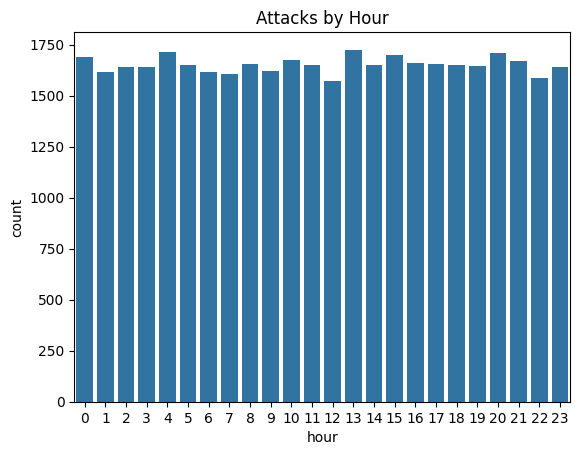

In [ ]:

# VISUALIZATION

sns.countplot(x='hour', data=df)
plt.title("Attacks by Hour")
plt.show()

In [ ]:

# MAP VISUALIZATION

map_center = [df['Latitude'].mean(), df['Longitude'].mean()]

attack_map = folium.Map(location=map_center, zoom_start=2)

for _, row in df.sample(min(2000, len(df))).iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2
    ).add_to(attack_map)

attack_map

In [ ]:
# Heatmap
heat_data = df[['Latitude','Longitude']].values.tolist()
heat_map = folium.Map(location=map_center, zoom_start=2)
HeatMap(heat_data).add_to(heat_map)

heat_map

In [ ]:

# DBSCAN CLUSTERING

coords = df[['Latitude','Longitude']].dropna()
coords_scaled = StandardScaler().fit_transform(coords)

db = DBSCAN(eps=0.3, min_samples=10)
df.loc[coords.index, 'Cluster'] = db.fit_predict(coords_scaled)

In [ ]:

# MACHINE LEARNING

df['High_Risk'] = df['Severity Level'].apply(
    lambda x: 1 if x in ['high','critical'] else 0
)

cat_cols = ['Protocol','Traffic Type','Attack Type','Country','City']
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

features = ['Latitude','Longitude','Protocol','Traffic Type',
            'Attack Type','Anomaly Scores','day_of_week']

# Balance dataset
df_majority = df[df.High_Risk == 0]
df_minority = df[df.High_Risk == 1]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

X = df_balanced[features]
y = df_balanced['High_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=2
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.6).astype(int)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5378270762229806
              precision    recall  f1-score   support

           0       0.69      0.14      0.23      5273
           1       0.52      0.94      0.67      5275

    accuracy                           0.54     10548
   macro avg       0.61      0.54      0.45     10548
weighted avg       0.61      0.54      0.45     10548



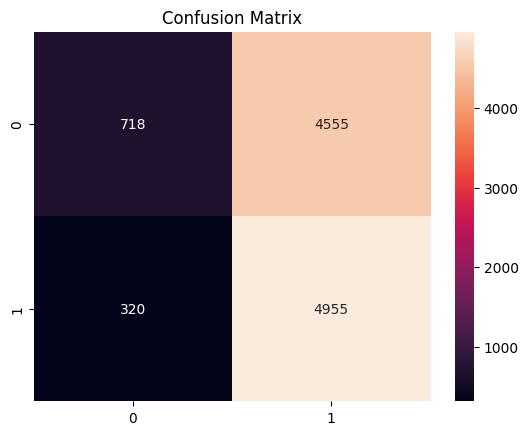

In [ ]:

# CONFUSION MATRIX

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:

# SPATIAL ANALYSIS (MORAN + Gi*)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

w = KNN.from_dataframe(gdf, k=5)
w.transform = 'r'

moran = Moran(gdf['Anomaly Scores'], w)
print("Moran’s I:", moran.I)

g_local = G_Local(gdf['Anomaly Scores'], w)
gdf['GiZScore'] = g_local.Zs

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 263 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Moran’s I: 0.0033900219814291884


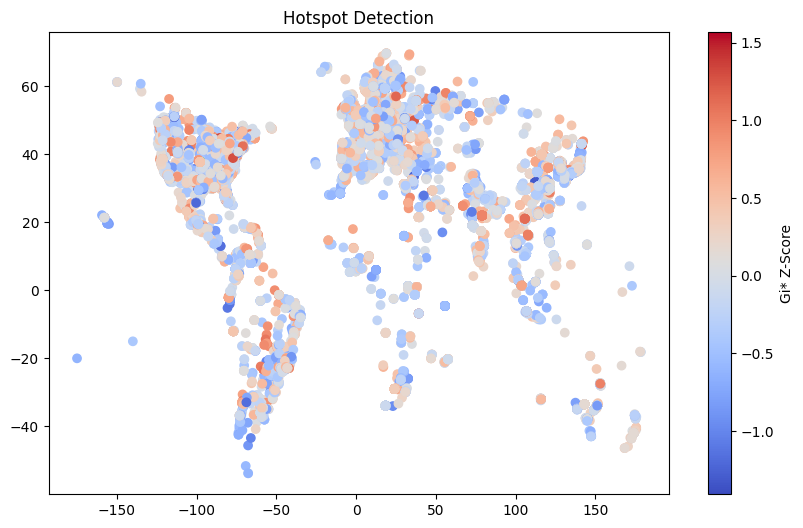

In [ ]:

# HOTSPOT VISUALIZATION

plt.figure(figsize=(10,6))
plt.scatter(gdf['Longitude'], gdf['Latitude'],
            c=gdf['GiZScore'], cmap='coolwarm')
plt.colorbar(label='Gi* Z-Score')
plt.title("Hotspot Detection")
plt.show()

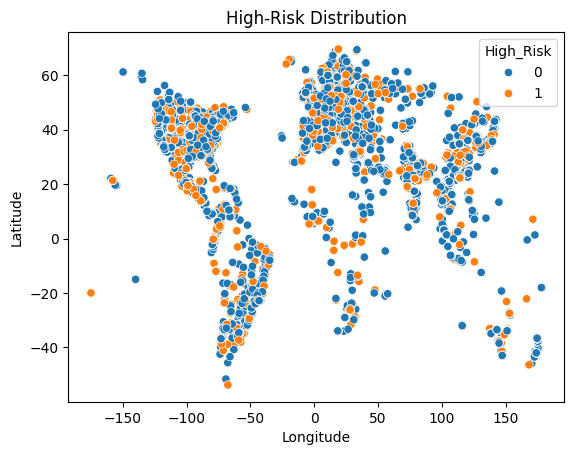

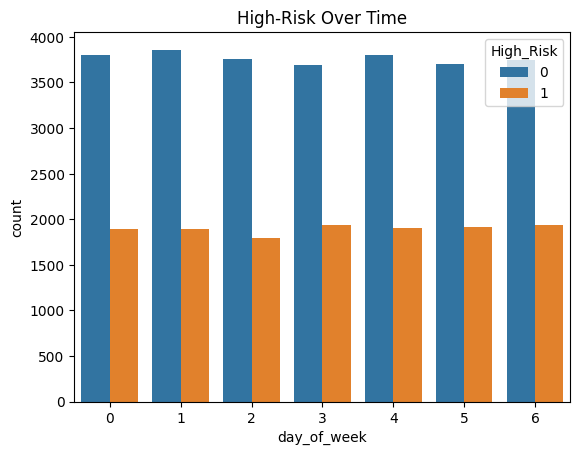

In [ ]:

# DASHBOARD PLOTS

sns.scatterplot(x='Longitude', y='Latitude', hue='High_Risk', data=df)
plt.title("High-Risk Distribution")
plt.show()

sns.countplot(x='day_of_week', hue='High_Risk', data=df)
plt.title("High-Risk Over Time")
plt.show()

In [ ]:
# ADVANCED FEATURE ENGINEERING


# Attack frequency per location
df['location_attack_count'] = df.groupby(['Latitude','Longitude'])['Cluster'].transform('count')

# Country-level attack frequency
df['country_attack_count'] = df.groupby('Country')['Cluster'].transform('count')

# Hour risk encoding
df['hour_risk'] = df.groupby('hour')['High_Risk'].transform('mean')

# Protocol risk encoding
df['protocol_risk'] = df.groupby('Protocol')['High_Risk'].transform('mean')

# Anomaly × Time interaction
df['anomaly_time'] = df['Anomaly Scores'] * df['hour']

# Cluster risk
df['cluster_risk'] = df.groupby('Cluster')['High_Risk'].transform('mean')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

RF Accuracy: 0.8049867273416762
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      5273
           1       0.78      0.85      0.81      5275

    accuracy                           0.80     10548
   macro avg       0.81      0.80      0.80     10548
weighted avg       0.81      0.80      0.80     10548



In [ ]:
xgboost = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=2
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.6).astype(int)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5378270762229806
              precision    recall  f1-score   support

           0       0.69      0.14      0.23      5273
           1       0.52      0.94      0.67      5275

    accuracy                           0.54     10548
   macro avg       0.61      0.54      0.45     10548
weighted avg       0.61      0.54      0.45     10548



In [ ]:
!pip install lightgbm
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(n_estimators=150)
lgb.fit(X_train, y_train)

lgb_preds = lgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, lgb_preds))
print(classification_report(y_test, lgb_preds))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21095, number of negative: 21097
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007348 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 781
[LightGBM] [Info] Number of data points in the train set: 42192, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499976 -> initscore=-0.000095
[LightGBM] [Info] Start training from score -0.000095
Accuracy: 0.5877891543420554
              precision    recall  f1-score   support

           0       0.59      0.57      0.58      5273
           1       0.58      0.61      0.60      5275

    accuracy                           0.59     10548
   macro avg       0.59      0.59      0.59     10548
weighted avg       0.59      0.59      0.59     10548



In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train)

cat_preds = cat.predict(X_test)
print("Accuracy:", accuracy_score(y_test, cat_preds))
print(classification_report(y_test, cat_preds))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00
Accuracy: 0.588832006067501
              precision    recall  f1-score   support

           0       0.59      0.57      0.58      5273
           1       0.59      0.61      0.60      5275

    accuracy                           0.59     10548
   macro avg       0.59      0.59      0.59     10548
weighted avg       0.59      0.59      0.59     10548



In [ ]:
final_preds = (
    preds + rf_preds + lgb_preds + cat_preds
) / 4

final_preds = (final_preds > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, final_preds))
print(classification_report(y_test, final_preds))

Accuracy: 0.6661926431551005
              precision    recall  f1-score   support

           0       0.67      0.65      0.66      5273
           1       0.66      0.69      0.67      5275

    accuracy                           0.67     10548
   macro avg       0.67      0.67      0.67     10548
weighted avg       0.67      0.67      0.67     10548



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_dl = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_dl.fit(X_train, y_train, epochs=10, batch_size=32)

dl_preds = (model_dl.predict(X_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, dl_preds))
print(classification_report(y_test, dl_preds))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1319/1319 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.5027 - loss: 0.7941
Epoch 2/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5043 - loss: 0.7327
Epoch 3/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5014 - loss: 0.7196
Epoch 4/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5078 - loss: 0.7139
Epoch 5/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5002 - loss: 0.7093
Epoch 6/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5048 - loss: 0.7035
Epoch 7/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5005 - loss: 0.6997
Epoch 8/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5037 - loss: 0.6979
Epoch 9/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5034 - loss: 0.6959
Epoch 10/10
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5017 - loss: 0.6948
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.49630261660978386
              precision    recall  f1-score   support

 